## Librerias

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Preprocesamiento compacto del dataset M5 para DeepAR

En este notebook prepararemos el dataset M5 para entrenar un modelo DeepAR.

A diferencia de un preprocesamiento tradicional, no convertiremos todo el dataset a formato largo, porque eso genera más de 58 millones de filas y puede saturar la RAM.

En su lugar, trabajaremos con un formato compacto:

- Una fila por serie de tiempo.
- Una matriz NumPy con las ventas históricas.
- Covariables estáticas por serie.
- Covariables temporales globales por día.

Este formato es más eficiente y es adecuado para construir después un dataset compatible con GluonTS/DeepAR.

## Datos

In [2]:
DATA_PATH = "/content/"

sales = pd.read_csv(DATA_PATH + "sales_train_validation.csv")
calendar = pd.read_csv(DATA_PATH + "calendar.csv")
prices = pd.read_csv(DATA_PATH + "sell_prices.csv")
submission = pd.read_csv(DATA_PATH + "sample_submission.csv")

calendar["date"] = pd.to_datetime(calendar["date"])

print("sales:", sales.shape)
print("calendar:", calendar.shape)
print("prices:", prices.shape)
print("submission:", submission.shape)

sales: (30490, 1919)
calendar: (1969, 14)
prices: (6841121, 4)
submission: (60980, 29)


In [3]:
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
date_cols = [col for col in sales.columns if col.startswith("d_")]

print("Número de columnas de días:", len(date_cols))
print("Primer día:", date_cols[0])
print("Último día:", date_cols[-1])

Número de columnas de días: 1913
Primer día: d_1
Último día: d_1913


## Selección inicial de subconjunto

El dataset completo tiene 30,490 series. Para empezar la réplica de DeepAR sin saturar memoria ni GPU, usaremos una sola tienda.

Usaremos `California` para no romper la RAM

In [4]:
STATE_ID = "CA"

sales_sub = sales[sales["state_id"] == STATE_ID].copy()

print("sales_sub:", sales_sub.shape)
print("Número de series:", sales_sub["id"].nunique())
print("Tiendas:", sales_sub["store_id"].unique())

sales_sub: (12196, 1919)
Número de series: 12196
Tiendas: ['CA_1' 'CA_2' 'CA_3' 'CA_4']


In [5]:
summary_sub = {
    "items": sales_sub["item_id"].nunique(),
    "departments": sales_sub["dept_id"].nunique(),
    "categories": sales_sub["cat_id"].nunique(),
    "stores": sales_sub["store_id"].nunique(),
    "states": sales_sub["state_id"].nunique()
}

summary_sub

{'items': 3049, 'departments': 7, 'categories': 3, 'stores': 4, 'states': 1}

## Matriz de ventas

Para DeepAR necesitamos que cada serie tenga su vector histórico de ventas.

Construiremos una matriz:

$$
\text{target_matrix} \in \mathbb{R}^{N \times T}
$$

donde:

- $N$ es el número de series.
- $T$ es el número de días históricos.

In [6]:
target_matrix = sales_sub[date_cols].values.astype("float32")

print("target_matrix:", target_matrix.shape)

target_matrix: (12196, 1913)


In [7]:
sales_sub["total_sales"] = target_matrix.sum(axis=1)
sales_sub["mean_sales"] = target_matrix.mean(axis=1)
sales_sub["zero_ratio"] = (target_matrix == 0).mean(axis=1)

sales_sub[["total_sales", "mean_sales", "zero_ratio"]].describe()

,total_sales,mean_sales,zero_ratio
count,12196.000000,12196.000000,12196.000000
mean,2351.225586,1.229078,0.662079
std,5481.928711,2.865619,0.230563
min,10.000000,0.005227,0.001568
25%,400.750000,0.209488,0.501830
50%,974.000000,0.509148,0.709880
75%,2286.250000,1.195112,0.855724
max,250502.000000,130.947205,0.996341


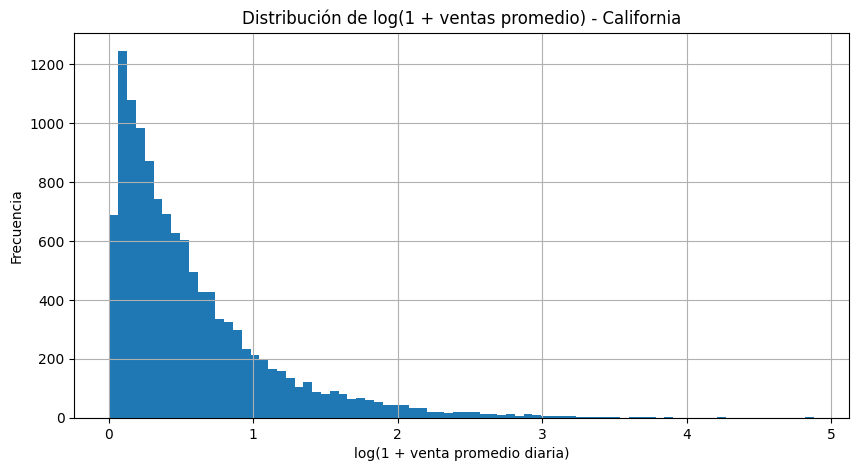

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(sales_sub["mean_sales"]), bins=80)
plt.title("Distribución de log(1 + ventas promedio) - California")
plt.xlabel("log(1 + venta promedio diaria)")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

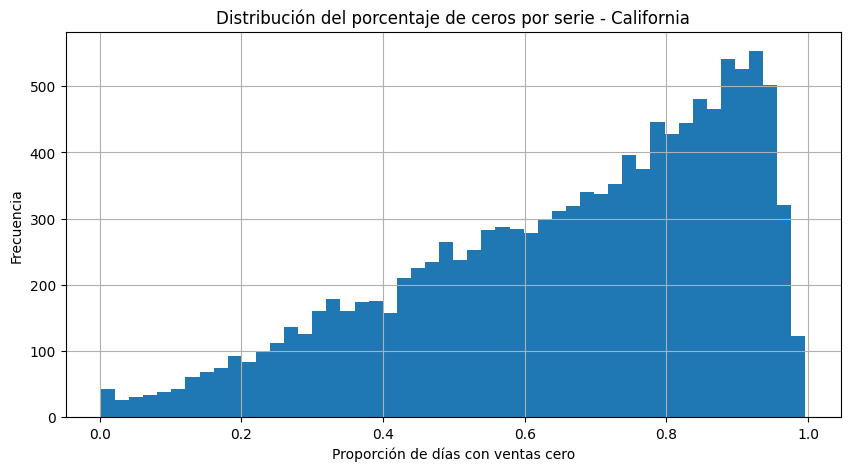

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(sales_sub["zero_ratio"], bins=50)
plt.title("Distribución del porcentaje de ceros por serie - California")
plt.xlabel("Proporción de días con ventas cero")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

## Covariables estáticas


DeepAR puede usar características estáticas de cada serie.

En M5, las covariables estáticas son:

- `item_id`
- `dept_id`
- `cat_id`
- `store_id`
- `state_id`

Estas variables ayudan al modelo a aprender patrones compartidos entre productos, departamentos, categorías y tiendas.

In [10]:
static_cat_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id"]

static_cats = sales_sub[static_cat_cols].copy()

static_cat_encoded = pd.DataFrame(index=sales_sub.index)
static_cardinalities = {}

for col in static_cat_cols:
    codes, uniques = pd.factorize(static_cats[col])
    static_cat_encoded[col] = codes.astype("int32")
    static_cardinalities[col] = len(uniques)

print(static_cat_encoded.shape)
print(static_cardinalities)
static_cat_encoded.head()

(12196, 5)
{'item_id': 3049, 'dept_id': 7, 'cat_id': 3, 'store_id': 4, 'state_id': 1}


,item_id,dept_id,cat_id,store_id,state_id
0,0,0,0,0,0
1,1,0,0,0,0
2,2,0,0,0,0
3,3,0,0,0,0
4,4,0,0,0,0


## Covariables temporales globales



Las covariables temporales dependen del día, no del producto.

Crearemos variables de calendario como:

- día de la semana
- día del mes
- semana del año
- mes
- año
- eventos
- SNAP

Estas variables son conocidas tanto en el pasado como en el futuro, por lo que son válidas para forecasting.

In [11]:
calendar_hist = calendar[calendar["d"].isin(date_cols)].copy()
calendar_hist = calendar_hist.sort_values("date").reset_index(drop=True)

print("calendar_hist:", calendar_hist.shape)
print("Días ventas:", len(date_cols))
print("Días calendario:", calendar_hist.shape[0])

assert len(date_cols) == calendar_hist.shape[0]

calendar_hist: (1913, 14)
Días ventas: 1913
Días calendario: 1913


In [12]:
time_features_clean = pd.DataFrame({
    "dayofweek": calendar_hist["date"].dt.dayofweek.astype("float32") / 6.0,
    "dayofmonth": (calendar_hist["date"].dt.day.astype("float32") - 1) / 30.0,
    "weekofyear": (calendar_hist["date"].dt.isocalendar().week.astype("float32") - 1) / 52.0,
    "month": (calendar_hist["date"].dt.month.astype("float32") - 1) / 11.0,
    "snap_CA": calendar_hist["snap_CA"].astype("float32"),
})

time_features_clean.head()

,dayofweek,dayofmonth,weekofyear,month,snap_CA
0,0.833333,0.933333,0.057692,0.000000,0.0
1,1.000000,0.966667,0.057692,0.000000,0.0
2,0.000000,1.000000,0.076923,0.000000,0.0
3,0.166667,0.000000,0.076923,0.090909,1.0
4,0.333333,0.033333,0.076923,0.090909,1.0


In [13]:
time_features_array = time_features_clean.values.astype("float32").T

print("time_features_array:", time_features_array.shape)
print("Faltantes:", np.isnan(time_features_array).sum())

time_features_array: (5, 1913)
Faltantes: 0


In [14]:
prediction_length = 28
context_length = 56

train_target_matrix = target_matrix[:, :-prediction_length]
valid_target_matrix = target_matrix.copy()

train_time_features_array = time_features_array[:, :-prediction_length]
valid_time_features_array = time_features_array.copy()

print("Train target:", train_target_matrix.shape)
print("Valid target:", valid_target_matrix.shape)
print("Train time features:", train_time_features_array.shape)
print("Valid time features:", valid_time_features_array.shape)

Train target: (12196, 1885)
Valid target: (12196, 1913)
Train time features: (5, 1885)
Valid time features: (5, 1913)


In [15]:
train_dates = calendar_hist.iloc[:-prediction_length]["date"]
forecast_dates = calendar_hist.iloc[-prediction_length:]["date"]

print("Inicio train:", train_dates.min())
print("Fin train:", train_dates.max())

print("Inicio validación:", forecast_dates.min())
print("Fin validación:", forecast_dates.max())

Inicio train: 2011-01-29 00:00:00
Fin train: 2016-03-27 00:00:00
Inicio validación: 2016-03-28 00:00:00
Fin validación: 2016-04-24 00:00:00


## Precios


El precio depende de:

- producto
- tienda
- semana

Por ahora no lo meteremos directamente como covariable dinámica porque eso requiere construir una matriz precio-serie-tiempo.

Para mantener el primer pipeline estable, entrenaremos primero DeepAR con:

- ventas históricas
- covariables estáticas
- covariables temporales globales

Después agregaremos `sell_price` como mejora.

In [16]:
ca_stores = sales_sub["store_id"].unique()

prices_sub = prices[prices["store_id"].isin(ca_stores)].copy()

print(prices_sub.shape)
prices_sub.head()

(2708822, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


## Archivos y validacion

In [17]:
print("Número de series:", target_matrix.shape[0])
print("Número de días históricos:", target_matrix.shape[1])
print("Número de covariables temporales:", time_features_array.shape[0])

print("Train target:", train_target_matrix.shape)
print("Valid target:", valid_target_matrix.shape)

print("Static cats:", static_cat_encoded.shape)

print("Faltantes en target:", np.isnan(target_matrix).sum())
print("Faltantes en time features:", np.isnan(time_features_array).sum())
print("Faltantes en static cats:", static_cat_encoded.isna().sum().sum())

Número de series: 12196
Número de días históricos: 1913
Número de covariables temporales: 5
Train target: (12196, 1885)
Valid target: (12196, 1913)
Static cats: (12196, 5)
Faltantes en target: 0
Faltantes en time features: 0
Faltantes en static cats: 0


In [19]:
OUTPUT_PATH = "/content/"

np.save(OUTPUT_PATH + "target_matrix_CA.npy", target_matrix)
np.save(OUTPUT_PATH + "train_target_matrix_CA.npy", train_target_matrix)
np.save(OUTPUT_PATH + "valid_target_matrix_CA.npy", valid_target_matrix)

np.save(OUTPUT_PATH + "time_features_array_CA.npy", time_features_array)
np.save(OUTPUT_PATH + "train_time_features_array_CA.npy", train_time_features_array)
np.save(OUTPUT_PATH + "valid_time_features_array_CA.npy", valid_time_features_array)

static_cat_encoded.to_parquet(OUTPUT_PATH + "static_cat_encoded_CA.parquet", index=False)

sales_sub[id_cols + ["total_sales", "mean_sales", "zero_ratio"]].to_parquet(
    OUTPUT_PATH + "series_metadata_CA.parquet",
    index=False
)

calendar_hist.to_parquet(OUTPUT_PATH + "calendar_hist_CA.parquet", index=False)
time_features_clean.to_parquet(OUTPUT_PATH + "time_features_full_CA.parquet", index=False)

with open(OUTPUT_PATH + "deepar_dataset_config_CA.pkl", "wb") as f:
    pickle.dump(
        {
            "freq": "D",
            "prediction_length": prediction_length,
            "context_length": context_length,
            "start_date": pd.Timestamp(calendar_hist["date"].min()),
            "static_cardinalities": static_cardinalities,
            "num_dynamic_features": time_features_array.shape[0],
        },
        f
    )

print("Archivos guardados correctamente.")

Archivos guardados correctamente.
